In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
import yfinance as yf


In [2]:
def get_stock_data(stock_symbol):
    df = yf.download(stock_symbol, period='5y')  
    return df

stock_symbol = 'AAPL'
df = get_stock_data(stock_symbol)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2019-12-05,64.368782,66.394997,66.472504,65.682503,65.947502,74424400
2019-12-06,65.612144,67.677498,67.750000,66.824997,66.870003,106075600
2019-12-09,64.693581,66.730003,67.699997,66.227501,67.500000,128042400
2019-12-10,65.071663,67.120003,67.517502,66.464996,67.150002,90420400
2019-12-11,65.626709,67.692497,67.775002,67.125000,67.202499,78756800


In [3]:

def add_features(df):
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['EMA50'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['RSI'] = calculate_RSI(df)
    df['Volatility'] = df['Close'].rolling(window=20).std()
    df['Momentum'] = df['Close'] - df['Close'].shift(14)
    df = df.dropna()
    return df

def calculate_RSI(data, window=14):
    delta = data['Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    RS = gain / loss
    RSI = 100 - (100 / (1 + RS))
    return RSI

df = add_features(df)
df.head()


Price,Adj Close,Close,High,Low,Open,Volume,MA50,EMA50,RSI,Volatility,Momentum
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,,
2020-02-18,77.499725,79.750000,79.937500,78.652496,78.839996,152531200,75.516550,76.266464,51.031981,1.341180,0.327499
2020-02-19,78.622131,80.904999,81.142502,80.000000,80.000000,93984000,75.806750,76.448367,49.414062,1.350506,-0.180000
2020-02-20,77.815552,80.074997,81.162498,79.552498,80.657501,100566000,76.054700,76.590588,47.223514,1.345462,-0.892502
2020-02-21,76.054192,78.262497,80.112503,77.625000,79.654999,129554000,76.285350,76.656153,53.095466,1.398297,0.884995
2020-02-24,72.441605,74.544998,76.044998,72.307503,74.315002,222195200,76.433849,76.573363,42.640446,1.840079,-2.620003


In [4]:

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'EMA50', 'RSI', 'Volatility', 'Momentum']])

X = scaled_data
y = df['Close'].values  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(X_train.shape, X_test.shape)


(967, 10) (242, 10)


In [5]:

rf = RandomForestRegressor()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf)}")


c:\Users\saura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest MSE: 404.2226267333147
Random Forest R2: 0.23069234815971074


In [6]:

nn = MLPRegressor(max_iter=500)

param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}

grid_search_nn = GridSearchCV(nn, param_grid_nn, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_nn.fit(X_train, y_train)

best_nn = grid_search_nn.best_estimator_
y_pred_nn = best_nn.predict(X_test)

print(f"Neural Network MSE: {mean_squared_error(y_test, y_pred_nn)}")
print(f"Neural Network R2: {r2_score(y_test, y_pred_nn)}")


c:\Users\saura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1631: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Neural Network MSE: 1.3476297339604297
Neural Network R2: 0.9974352205996938


c:\Users\saura\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Blended MSE: 103.48620629095878
Blended R2: 0.8030473182490062


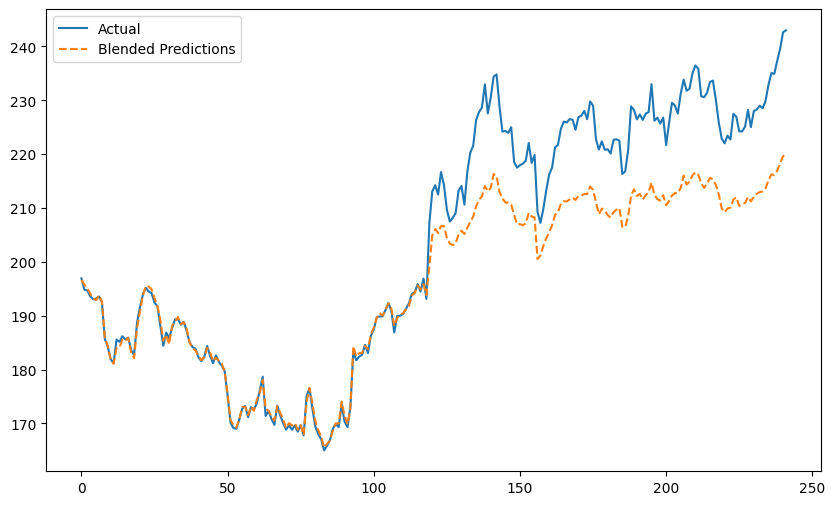

In [7]:

y_pred_blended = (y_pred_rf + y_pred_nn) / 2

print(f"Blended MSE: {mean_squared_error(y_test, y_pred_blended)}")
print(f"Blended R2: {r2_score(y_test, y_pred_blended)}")

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_blended, label='Blended Predictions', linestyle='--')
plt.legend()
plt.show()


Text(value='AAPL', description='Stock:')

IntSlider(value=6, description='Months:', max=24, min=1)

Button(description='Predict Stock Prices', style=ButtonStyle())

[*********************100%***********************]  1 of 1 completed


ValueError: x and y must have same first dimension, but have shapes (180,) and (6,)

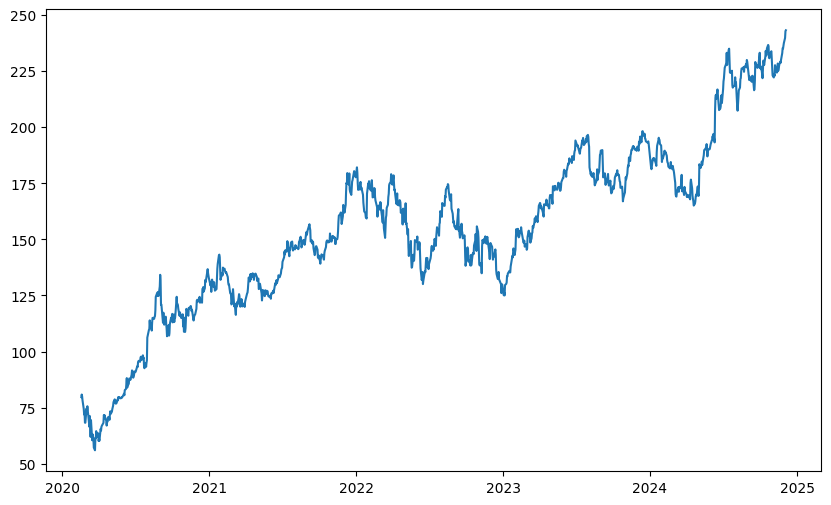

In [8]:
import ipywidgets as widgets
from IPython.display import display

stock_input = widgets.Text(value='AAPL', description='Stock:')
months_slider = widgets.IntSlider(value=6, min=1, max=24, description='Months:')

predict_button = widgets.Button(description="Predict Stock Prices")

def predict_future_prices(b):
    stock_symbol = stock_input.value
    months = months_slider.value
    df = get_stock_data(stock_symbol)
    df = add_features(df)
    
    X_full = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'EMA50', 'RSI', 'Volatility', 'Momentum']])
    best_rf.fit(X_full, df['Close'])
    best_nn.fit(X_full, df['Close'])
    
    future_dates = pd.date_range(df.index[-1], periods=months*30, freq='D')
    future_prices_rf = best_rf.predict(X_full[-months:])
    future_prices_nn = best_nn.predict(X_full[-months:])
    future_prices_blended = (future_prices_rf + future_prices_nn) / 2
    
    plt.figure(figsize=(10, 6))
    plt.plot(df.index, df['Close'], label='Historical Prices')
    plt.plot(future_dates, future_prices_blended, label='Predicted Prices', linestyle='--')
    plt.legend()
    plt.show()

predict_button.on_click(predict_future_prices)

display(stock_input, months_slider, predict_button)


In [9]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
import yfinance as yf
import warnings
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore")


In [10]:

def get_stock_data(stock_symbol):
    df = yf.download(stock_symbol, period='5y')  
    return df

stock_symbol = 'AAPL'  
df = get_stock_data(stock_symbol)
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2019-12-05,64.368774,66.394997,66.472504,65.682503,65.947502,74424400
2019-12-06,65.612160,67.677498,67.750000,66.824997,66.870003,106075600
2019-12-09,64.693573,66.730003,67.699997,66.227501,67.500000,128042400
2019-12-10,65.071671,67.120003,67.517502,66.464996,67.150002,90420400
2019-12-11,65.626686,67.692497,67.775002,67.125000,67.202499,78756800


In [11]:

def add_features(df):
   
    df['MA50'] = df['Close'].rolling(window=50).mean()
    df['EMA50'] = df['Close'].ewm(span=50, adjust=False).mean()
    
    df['Volatility'] = df['Close'].rolling(window=20).std()
    
    df['Momentum'] = df['Close'] - df['Close'].shift(14)
    
    df['RSI'] = calculate_RSI(df)
    
    df['Upper_BB'] = df['MA50'] + (2 * df['Volatility'])
    df['Lower_BB'] = df['MA50'] - (2 * df['Volatility'])
    
    df = df.dropna()  
    return df

def calculate_RSI(data, window=14):
    delta = data['Close'].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    RS = gain / loss
    RSI = 100 - (100 / (1 + RS))
    return RSI

df = add_features(df)
df.head()


Price,Adj Close,Close,High,Low,Open,Volume,MA50,EMA50,Volatility,Momentum,RSI,Upper_BB,Lower_BB
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
Date,,,,,,,,,,,,,
2020-02-18,77.499733,79.750000,79.937500,78.652496,78.839996,152531200,75.516550,76.266464,1.341180,0.327499,51.031981,78.198909,72.834190
2020-02-19,78.622147,80.904999,81.142502,80.000000,80.000000,93984000,75.806750,76.448367,1.350506,-0.180000,49.414062,78.507762,73.105737
2020-02-20,77.815559,80.074997,81.162498,79.552498,80.657501,100566000,76.054700,76.590588,1.345462,-0.892502,47.223514,78.745624,73.363775
2020-02-21,76.054199,78.262497,80.112503,77.625000,79.654999,129554000,76.285350,76.656153,1.398297,0.884995,53.095466,79.081944,73.488755
2020-02-24,72.441605,74.544998,76.044998,72.307503,74.315002,222195200,76.433849,76.573363,1.840079,-2.620003,42.640446,80.114007,72.753692


In [12]:

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA50', 'EMA50', 'RSI', 'Volatility', 'Momentum', 'Upper_BB', 'Lower_BB']])

X = scaled_data
y = df['Close'].values  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(X_train.shape, X_test.shape)


(967, 12) (242, 12)


In [13]:

rf = RandomForestRegressor()

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

grid_search_rf = GridSearchCV(rf, param_grid_rf, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf)}")


Random Forest MSE: 408.516838544441
Random Forest R2: 0.2225196982721478


In [14]:

nn = MLPRegressor(max_iter=500)

param_grid_nn = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}

grid_search_nn = GridSearchCV(nn, param_grid_nn, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search_nn.fit(X_train, y_train)

best_nn = grid_search_nn.best_estimator_
y_pred_nn = best_nn.predict(X_test)

print(f"Neural Network MSE: {mean_squared_error(y_test, y_pred_nn)}")
print(f"Neural Network R2: {r2_score(y_test, y_pred_nn)}")


Neural Network MSE: 5.396784903559385
Neural Network R2: 0.9897289571462224


Blended MSE: 105.56796551020786
Blended R2: 0.7990853596877059


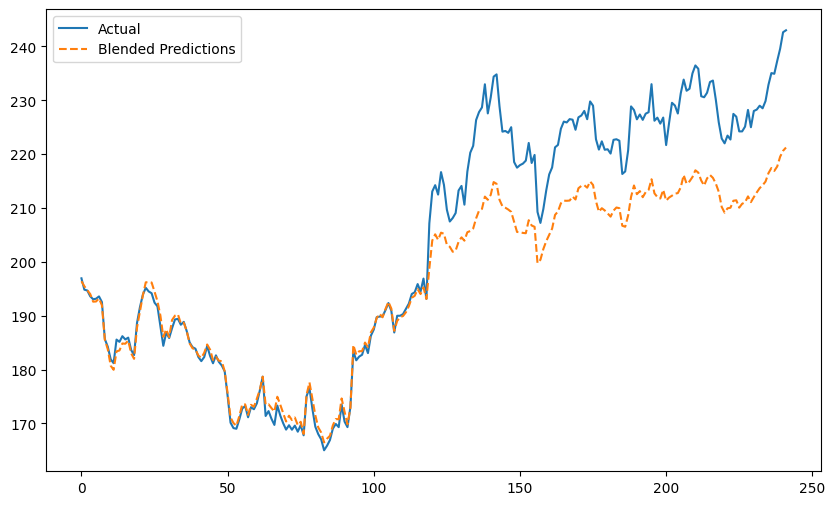

In [15]:

y_pred_blended = (y_pred_rf + y_pred_nn) / 2

print(f"Blended MSE: {mean_squared_error(y_test, y_pred_blended)}")
print(f"Blended R2: {r2_score(y_test, y_pred_blended)}")

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred_blended, label='Blended Predictions', linestyle='--')
plt.legend()
plt.show()
